In [2]:
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import defaultdict

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from inference.preprocessing import Preprocessing
from inference.object_detection import Model
from inference.nms import NMS

def load_annotations(annotation_path):
    with open(annotation_path, 'r') as f:
        return [tuple(map(float, line.strip().split())) for line in f]

def calculate_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    intersection_area = max(0, min(x1+w1, x2+w2) - max(x1, x2)) * max(0, min(y1+h1, y2+h2) - max(y1, y2))
    union_area = w1*h1 + w2*h2 - intersection_area
    return intersection_area / union_area if union_area > 0 else 0

def evaluate_model(model, dataset_path, iou_threshold=0.5, input_size=416):
    nms = NMS(nms_iou_threshold=0.4)
    
    total_time = 0
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for image_file in os.listdir(dataset_path):
        if image_file.endswith('.jpg'):
            image_path = os.path.join(dataset_path, image_file)
            annotation_path = os.path.join(dataset_path, image_file.replace('.jpg', '.txt'))
            
            # Load image and annotations
            image = cv2.imread(image_path)
            gt_annotations = load_annotations(annotation_path)
            
            # Model prediction
            start_time = time.time()
            predictions = model.predict(image, input_size)
            bboxes, class_ids, scores = model.post_process(predictions, score_threshold=0.5)
            filtered_bboxes, filtered_class_ids, filtered_scores = nms.filter(bboxes, class_ids, scores)
            end_time = time.time()
            
            total_time += (end_time - start_time)
            
            h, w = image.shape[:2]
            gt_boxes = [(int((x - width/2) * w), int((y - height/2) * h), int(width * w), int(height * h)) 
                        for _, x, y, width, height in gt_annotations]
            
            # Evaluate detections
            detected = [False] * len(gt_boxes)
            for pred_box, pred_class in zip(filtered_bboxes, filtered_class_ids):
                max_iou = 0
                max_idx = -1
                for i, gt_box in enumerate(gt_boxes):
                    iou = calculate_iou(pred_box, gt_box)
                    if iou > max_iou:
                        max_iou = iou
                        max_idx = i
                
                if max_iou >= iou_threshold:
                    if not detected[max_idx]:
                        true_positives += 1
                        detected[max_idx] = True
                else:
                    false_positives += 1
            
            false_negatives += sum(1 for d in detected if not d)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    avg_time = total_time / len([f for f in os.listdir(dataset_path) if f.endswith('.jpg')])
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'avg_inference_time': avg_time
    }

def evaluate_per_class(model, dataset_path, iou_threshold=0.5):
    nms = NMS(nms_iou_threshold=0.4)
    class_metrics = defaultdict(lambda: defaultdict(int))
    
    for image_file in [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]:
        image_path = os.path.join(dataset_path, image_file)
        annotation_path = os.path.join(dataset_path, image_file.replace('.jpg', '.txt'))
        
        image = cv2.imread(image_path)
        gt_annotations = load_annotations(annotation_path)
        
        predictions = model.predict(image)
        bboxes, class_ids, scores = model.post_process(predictions, score_threshold=0.5)
        filtered_bboxes, filtered_class_ids, filtered_scores = nms.filter(bboxes, class_ids, scores)
        
        h, w = image.shape[:2]
        gt_boxes = [(int((x - width/2) * w), int((y - height/2) * h), int(width * w), int(height * h)) 
                    for _, x, y, width, height in gt_annotations]
        gt_classes = [class_id for class_id, *_ in gt_annotations]
        
        detected = [False] * len(gt_boxes)
        for pred_box, pred_class in zip(filtered_bboxes, filtered_class_ids):
            best_iou = max((calculate_iou(pred_box, gt_box), i) for i, gt_box in enumerate(gt_boxes))
            if best_iou[0] >= iou_threshold and not detected[best_iou[1]]:
                class_metrics[pred_class]['true_positives'] += 1
                detected[best_iou[1]] = True
            else:
                class_metrics[pred_class]['false_positives'] += 1
        
        for gt_class, is_detected in zip(gt_classes, detected):
            if not is_detected:
                class_metrics[gt_class]['false_negatives'] += 1
    
    for class_id in class_metrics:
        metrics = class_metrics[class_id]
        metrics['precision'] = metrics['true_positives'] / (metrics['true_positives'] + metrics['false_positives']) if (metrics['true_positives'] + metrics['false_positives']) > 0 else 0
        metrics['recall'] = metrics['true_positives'] / (metrics['true_positives'] + metrics['false_negatives']) if (metrics['true_positives'] + metrics['false_negatives']) > 0 else 0
        metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall']) if (metrics['precision'] + metrics['recall']) > 0 else 0
    
    return class_metrics

def precision_recall_curve(model, dataset_path):
    nms = NMS(nms_iou_threshold=0.4)
    all_scores = []
    all_true_positives = []
    num_gt = 0
    
    for image_file in [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]:
        image_path = os.path.join(dataset_path, image_file)
        annotation_path = os.path.join(dataset_path, image_file.replace('.jpg', '.txt'))
        
        image = cv2.imread(image_path)
        gt_annotations = load_annotations(annotation_path)
        
        predictions = model.predict(image)
        bboxes, class_ids, scores = model.post_process(predictions, score_threshold=0.01)  # Lower threshold for PR curve
        filtered_bboxes, filtered_class_ids, filtered_scores = nms.filter(bboxes, class_ids, scores)
        
        h, w = image.shape[:2]
        gt_boxes = [(int((x - width/2) * w), int((y - height/2) * h), int(width * w), int(height * h)) 
                    for _, x, y, width, height in gt_annotations]
        
        num_gt += len(gt_boxes)
        detected = [False] * len(gt_boxes)
        
        for pred_box, score in zip(filtered_bboxes, filtered_scores):
            all_scores.append(score)
            best_iou = max((calculate_iou(pred_box, gt_box), i) for i, gt_box in enumerate(gt_boxes))
            if best_iou[0] >= 0.5 and not detected[best_iou[1]]:
                all_true_positives.append(1)
                detected[best_iou[1]] = True
            else:
                all_true_positives.append(0)
    
    sorted_indices = sorted(range(len(all_scores)), key=lambda i: all_scores[i], reverse=True)
    all_scores = [all_scores[i] for i in sorted_indices]
    all_true_positives = [all_true_positives[i] for i in sorted_indices]
    
    cumulative_true_positives = np.cumsum(all_true_positives)
    precisions = cumulative_true_positives / np.arange(1, len(cumulative_true_positives) + 1)
    recalls = cumulative_true_positives / num_gt
    
    return precisions, recalls, all_scores

def analyze_errors(model, dataset_path):
    nms = NMS(nms_iou_threshold=0.4)
    error_analysis = defaultdict(int)
    
    for image_file in [f for f in os.listdir(dataset_path) if f.endswith('.jpg')]:
        image_path = os.path.join(dataset_path, image_file)
        annotation_path = os.path.join(dataset_path, image_file.replace('.jpg', '.txt'))
        
        image = cv2.imread(image_path)
        gt_annotations = load_annotations(annotation_path)
        
        predictions = model.predict(image)
        bboxes, class_ids, scores = model.post_process(predictions, score_threshold=0.5)
        filtered_bboxes, filtered_class_ids, filtered_scores = nms.filter(bboxes, class_ids, scores)
        
        h, w = image.shape[:2]
        gt_boxes = [(int((x - width/2) * w), int((y - height/2) * h), int(width * w), int(height * h)) 
                    for _, x, y, width, height in gt_annotations]
        gt_classes = [class_id for class_id, *_ in gt_annotations]
        
        detected = [False] * len(gt_boxes)
        for pred_box, pred_class in zip(filtered_bboxes, filtered_class_ids):
            best_iou = max((calculate_iou(pred_box, gt_box), i) for i, gt_box in enumerate(gt_boxes))
            if best_iou[0] >= 0.5:
                if pred_class == gt_classes[best_iou[1]]:
                    error_analysis['correct_detections'] += 1
                else:
                    error_analysis['misclassifications'] += 1
                detected[best_iou[1]] = True
            else:
                error_analysis['false_positives'] += 1
        
        error_analysis['false_negatives'] += sum(1 for d in detected if not d)
    
    return error_analysis

def evaluate_speed_accuracy_tradeoff(model, dataset_path):
    thresholds = np.arange(0.1, 1.0, 0.1)
    results = []
    
    for threshold in thresholds:
        start_time = time.time()
        metrics = evaluate_model(model, dataset_path, iou_threshold=threshold)
        end_time = time.time()
        
        results.append({
            'threshold': threshold,
            'mAP': (metrics['precision'] + metrics['recall']) / 2,  # Simple average precision as mAP
            'inference_time': end_time - start_time
        })
    
    return results

def compare_model_complexity(model1, model2):
    return {
        'model1': {
            'num_parameters': sum(p.numel() for p in model1.net.parameters()),
            'model_size': os.path.getsize(model1.weights_path) / (1024 * 1024)  
        },
        'model2': {
            'num_parameters': sum(p.numel() for p in model2.net.parameters()),
            'model_size': os.path.getsize(model2.weights_path) / (1024 * 1024) 
        }
    }

def visualize_overall_metrics(results1, results2):
    metrics = ['precision', 'recall', 'f1_score', 'avg_inference_time']
    model1_values = [results1[metric] for metric in metrics]
    model2_values = [results2[metric] for metric in metrics]

    plt.figure(figsize=(12, 6))
    x = range(len(metrics))
    width = 0.35

    plt.bar([i - width/2 for i in x], model1_values, width, label='Model 1')
    plt.bar([i + width/2 for i in x], model2_values, width, label='Model 2')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.title('Model Performance Comparison')
    plt.xticks(x, metrics)
    plt.legend()

    plt.tight_layout()
    plt.show()

def visualize_per_class_metrics(class_results1, class_results2):
    all_classes = set(list(class_results1.keys()) + list(class_results2.keys()))
    metrics = ['precision', 'recall', 'f1_score']
    
    fig, axs = plt.subplots(len(metrics), 1, figsize=(12, 5*len(metrics)), squeeze=False)
    fig.suptitle('Per-Class Metrics Comparison', fontsize=16)
    
    bar_width = 0.35
    
    for i, metric in enumerate(metrics):
        model1_values = []
        model2_values = []
        
        for class_id in all_classes:
            model1_values.append(class_results1.get(class_id, {}).get(metric, 0))
            model2_values.append(class_results2.get(class_id, {}).get(metric, 0))
        
        r1 = np.arange(len(all_classes))
        r2 = [x + bar_width for x in r1]
        
        axs[i, 0].bar(r1, model1_values, color='skyblue', width=bar_width, label='Model 1')
        axs[i, 0].bar(r2, model2_values, color='orange', width=bar_width, label='Model 2')
        
        axs[i, 0].set_xlabel('Class ID')
        axs[i, 0].set_ylabel(metric.capitalize())
        axs[i, 0].set_title(f'Per-Class {metric.capitalize()}')
        axs[i, 0].set_xticks([r + bar_width/2 for r in range(len(all_classes))])
        axs[i, 0].set_xticklabels(all_classes)
        axs[i, 0].legend()
        
        for j, v in enumerate(model1_values):
            axs[i, 0].text(j, v, f'{v:.2f}', ha='center', va='bottom')
        for j, v in enumerate(model2_values):
            axs[i, 0].text(j + bar_width, v, f'{v:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

def plot_precision_recall_curves(precisions1, recalls1, precisions2, recalls2):
    plt.figure(figsize=(10, 6))
    plt.plot(recalls1, precisions1, label='Model 1')
    plt.plot(recalls2, precisions2, label='Model 2')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves')
    plt.legend()
    plt.show()

def visualize_error_analysis(error_analysis1, error_analysis2):

    error_labels = list(error_analysis1.keys())
    
    error_counts1 = [error_analysis1[label] for label in error_labels]
    error_counts2 = [error_analysis2[label] for label in error_labels]
    
    bar_width = 0.35  
    index = np.arange(len(error_labels))  
    
    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.bar(index, error_counts1, bar_width, label='Model 1', color='blue')
    plt.bar(index + bar_width, error_counts2, bar_width, label='Model 2', color='orange')
    
    plt.xlabel('Error Types')
    plt.ylabel('Count')
    plt.title('Error Analysis Bar Chart (Model 1 vs Model 2)')
    plt.xticks(index + bar_width / 2, error_labels, rotation=45)
    plt.legend()
    
    plt.subplot(2, 2, 2)
    plt.pie(error_counts1, labels=error_labels, autopct='%1.1f%%', colors=['green', 'red', 'orange', 'blue'])
    plt.title('Model 1 Error Analysis Distribution')
    
    plt.subplot(2, 2, 4)
    plt.pie(error_counts2, labels=error_labels, autopct='%1.1f%%', colors=['green', 'red', 'orange', 'blue'])
    plt.title('Model 2 Error Analysis Distribution')

    plt.tight_layout()
    plt.show()

def plot_speed_accuracy_tradeoff(speed_accuracy1, speed_accuracy2):
    plt.figure(figsize=(10, 6))
    plt.scatter(speed_accuracy1['speed'], speed_accuracy1['accuracy'], label='Model 1')
    plt.scatter(speed_accuracy2['speed'], speed_accuracy2['accuracy'], label='Model 2')
    plt.xlabel('Inference Speed (ms)')
    plt.ylabel('mAP')
    plt.title('Speed-Accuracy Trade-off')
    plt.legend()
    plt.show()

In [3]:
def evaluate_model(model, dataset_path, iou_threshold=0.5, input_size=416, score_threshold=0.5, hard_negatives_dir='../storage/hard_negatives_0.1'):
    nms = NMS(nms_iou_threshold=iou_threshold)
    
    total_time = 0
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    all_precisions = []
    all_recalls = []
    
    average_precisions = {}
    classes_detected = set()
    
    for image_file in os.listdir(dataset_path):
        if image_file.endswith('.jpg'):
            image_path = os.path.join(dataset_path, image_file)
            annotation_path = os.path.join(dataset_path, image_file.replace('.jpg', '.txt'))
            
            # Load image and annotations
            image = cv2.imread(image_path)
            gt_annotations = load_annotations(annotation_path)
            
            # Model prediction
            start_time = time.time()
            predictions = model.predict(image, input_size)
            bboxes, class_ids, scores = model.post_process(predictions, score_threshold=score_threshold)
            filtered_bboxes, filtered_class_ids, filtered_scores = nms.filter(bboxes, class_ids, scores)
            end_time = time.time()
            
            total_time += (end_time - start_time)
            
            h, w = image.shape[:2]
            gt_boxes = [(int((x - width/2) * w), int((y - height/2) * h), int(width * w), int(height * h)) 
                        for _, x, y, width, height in gt_annotations]
            
            # Initialize detection status for GT boxes
            detected = [False] * len(gt_boxes)
            class_true_positives = {class_id: 0 for class_id in classes_detected}
            class_false_positives = {class_id: 0 for class_id in classes_detected}
            class_false_negatives = {class_id: 0 for class_id in classes_detected}
            
            # Evaluate detections
            for pred_box, pred_class in zip(filtered_bboxes, filtered_class_ids):
                max_iou = 0
                max_idx = -1
                for i, gt_box in enumerate(gt_boxes):
                    iou = calculate_iou(pred_box, gt_box)
                    if iou > max_iou:
                        max_iou = iou
                        max_idx = i
                
                if max_iou >= iou_threshold:
                    if not detected[max_idx]:
                        true_positives += 1
                        detected[max_idx] = True
                        # class_true_positives[pred_class] += 1
                    else:
                        false_positives += 1
                        # class_false_positives[pred_class] += 1
                else:
                    false_positives += 1
                    # class_false_positives[pred_class] += 1

            # Count false negatives
            false_negatives += sum(1 for d in detected if not d)
            # class_false_negatives[pred_class] += sum(1 for d in detected if not d)

            # Calculate precision and recall per image
            precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
            recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
            all_precisions.append(precision)
            all_recalls.append(recall)

            # Collect class-specific metrics for mAP
            if pred_class in average_precisions:
                average_precisions[pred_class].append(precision)
            else:
                average_precisions[pred_class] = [precision]
    
    # Calculate mAP for all classes
    mean_average_precision = sum([sum(precisions) / len(precisions) for precisions in average_precisions.values()]) / len(average_precisions)
    
    # Calculate global precision, recall, and f1-score
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    avg_time = total_time / len([f for f in os.listdir(dataset_path) if f.endswith('.jpg')])
    
    return {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'avg_inference_time': avg_time,
        'mean_average_precision': mean_average_precision,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }


In [6]:
model2 = Model(config_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
                weights_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
                class_names_path="../yolo_model_2/logistics.names")

num_samples_percentage = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for p in num_samples_percentage:
    dataset_path = f'../storage/hard_negatives_{p}'
    result = evaluate_model(model=model2, dataset_path=dataset_path)
    print(result)

{'precision': 0.7287934511804485, 'recall': 0.3311768828508275, 'f1_score': 0.45540811031210615, 'avg_inference_time': 0.025369264999357592, 'mean_average_precision': 0.7371324946925335, 'false_positives': 2286, 'false_negatives': 12406}
{'precision': 0.7614647206149063, 'recall': 0.3588230506267296, 'f1_score': 0.4877873364498907, 'avg_inference_time': 0.025176515854562674, 'mean_average_precision': 0.768226863804256, 'false_positives': 2762, 'false_negatives': 15755}
{'precision': 0.7650387596899225, 'recall': 0.35693876812904624, 'f1_score': 0.48676909418234726, 'avg_inference_time': 0.025134450453830674, 'mean_average_precision': 0.7670527362800478, 'false_positives': 3031, 'false_negatives': 17780}
{'precision': 0.7754767274964117, 'recall': 0.3765057242409159, 'f1_score': 0.5069025599785552, 'avg_inference_time': 0.025094960242744505, 'mean_average_precision': 0.7774223524356769, 'false_positives': 3285, 'false_negatives': 18789}
{'precision': 0.768892149669846, 'recall': 0.36951

In [ ]:
model2 = Model(config_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
                weights_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
                class_names_path="../yolo_model_2/logistics.names")

dataset_path = '../logistics'
input_sizes = [224, 320, 416, 512, 608]
for size in input_sizes:
    result = evaluate_model(model=model2, dataset_path=dataset_path, input_size=size)
    print(result)

{'precision': 0.7142646480534801, 'recall': 0.39571362435663515, 'f1_score': 0.509278892491019, 'avg_inference_time': 0.04033425664025655, 'mean_average_precision': 0.715498046399459, 'false_positives': 5813, 'false_negatives': 22190}


In [ ]:
IOU_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for threshold in IOU_thresholds:
    result = evaluate_model(model=model2, dataset_path=dataset_path, iou_threshold=threshold)
    print(result)

{'precision': 0.9604804079441761, 'recall': 0.38983143160589306, 'f1_score': 0.5545762711864407, 'avg_inference_time': 0.021146204640546184, 'mean_average_precision': 0.9622735436177775, 'false_positives': 589, 'false_negatives': 22406}
{'precision': 0.9109801821103375, 'recall': 0.4631682143732469, 'f1_score': 0.614106984889242, 'avg_inference_time': 0.021284390421990023, 'mean_average_precision': 0.914854010338987, 'false_positives': 1662, 'false_negatives': 19713}
{'precision': 0.8971871968962173, 'recall': 0.4786089703439449, 'f1_score': 0.6242230509678566, 'avg_inference_time': 0.021133500822572884, 'mean_average_precision': 0.9017955100398467, 'false_positives': 2014, 'false_negatives': 19146}


In [ ]:
score_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in score_thresholds:
    result = evaluate_model(model=model2, dataset_path=dataset_path, score_threshold=threshold)
    print(result)

{'precision': 0.9192836979534227, 'recall': 0.28378856784945944, 'f1_score': 0.4336933225128493, 'avg_inference_time': 0.023791057681787044, 'mean_average_precision': 0.9220981532888418, 'false_positives': 915, 'false_negatives': 26300}
{'precision': 0.9553188725808547, 'recall': 0.2002941096375371, 'f1_score': 0.3311571364250338, 'avg_inference_time': 0.023424070012851024, 'mean_average_precision': 0.9562046600267365, 'false_positives': 344, 'false_negatives': 29366}


In [ ]:
model2 = Model(config_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
                weights_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
                class_names_path="../yolo_model_2/logistics.names")

augmentations = ["storage/augment/Original", "storage/augment/Horizontal_Flip", "storage/augment/Gaussian_Blur", "storage/augment/Resize_75", "storage/augment/Rotate_90", "storage/augment/Brightness_50", "storage/augment/Add_Noise"]
for path in augmentations:
    result = evaluate_model(model=model2, dataset_path=path)
    print(result)

{'precision': 0.8279334500875657, 'recall': 0.4678377041068778, 'f1_score': 0.5978501422699969, 'avg_inference_time': 0.023898674964904786}
{'precision': 0.821098901098901, 'recall': 0.46214745175655614, 'f1_score': 0.5914199778375812, 'avg_inference_time': 0.023781829595565795}
{'precision': 0.8550254747568319, 'recall': 0.45670460168233545, 'f1_score': 0.5953878406708596, 'avg_inference_time': 0.02378464651107788}
{'precision': 0.8589371980676328, 'recall': 0.43988124690747155, 'f1_score': 0.581806282722513, 'avg_inference_time': 0.023788095712661744}
{'precision': 0.7580645161290323, 'recall': 0.1744186046511628, 'f1_score': 0.2835880933226066, 'avg_inference_time': 0.023720123052597047}
{'precision': 0.8366963866729236, 'recall': 0.44111825828797624, 'f1_score': 0.5776769803985096, 'avg_inference_time': 0.02379130220413208}
{'precision': 0.8267132256656482, 'recall': 0.4685799109351806, 'f1_score': 0.5981367440391598, 'avg_inference_time': 0.023749043226242064}


Visualize metrics:


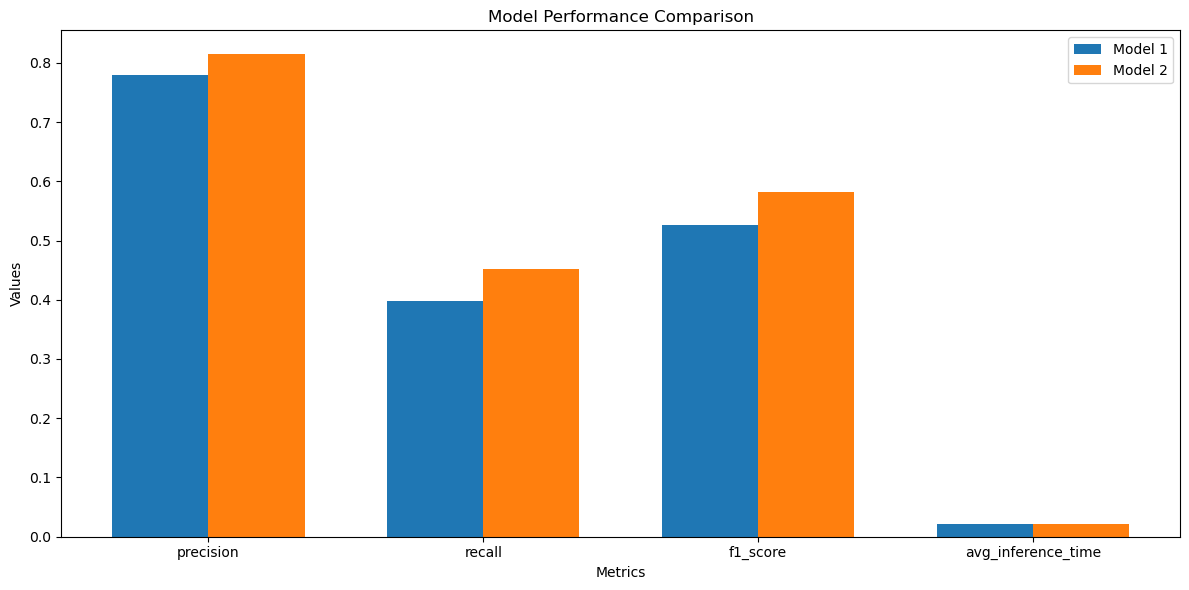

In [ ]:
# Load and evaluate both models
model1 = Model(config_path="../yolo_model_1/yolov4-tiny-logistics_size_416_1.cfg",
                weights_path="../yolo_model_1/yolov4-tiny-logistics_size_416_1.weights",
                class_names_path="../yolo_model_1/logistics.names")

model2 = Model(config_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.cfg",
                weights_path="../yolo_model_2/yolov4-tiny-logistics_size_416_2.weights",
                class_names_path="../yolo_model_2/logistics.names")

dataset_path = '../logistics'

# Overall model evaluation
results1 = evaluate_model(model1, dataset_path)
results2 = evaluate_model(model2, dataset_path)

print("Visualize metrics:")
visualize_overall_metrics(results1, results2)

`The bar graph above shows that Model 2 consistently outperforms Model 1 in terms of precision, recall, and F1 score, indicating that Model 2 is better at both accurately identifying true positives and minimizing false positives. Higher precision means Model 2 is more reliable in its predictions, producing fewer incorrect detections relative to the correct ones. The higher recall reflects that Model 2 captures a greater number of actual positive instances, meaning it misses fewer objects in its detections. The F1 score, which balances precision and recall, highlights Model 2’s overall robustness and superior performance in handling both accuracy and completeness in detection tasks. Despite these improvements in prediction quality, the similar average inference time between the two models suggests that Model 2 achieves this better performance without sacrificing speed, making it a more efficient and effective model for real-time applications.`

Visualize per-class metrics:


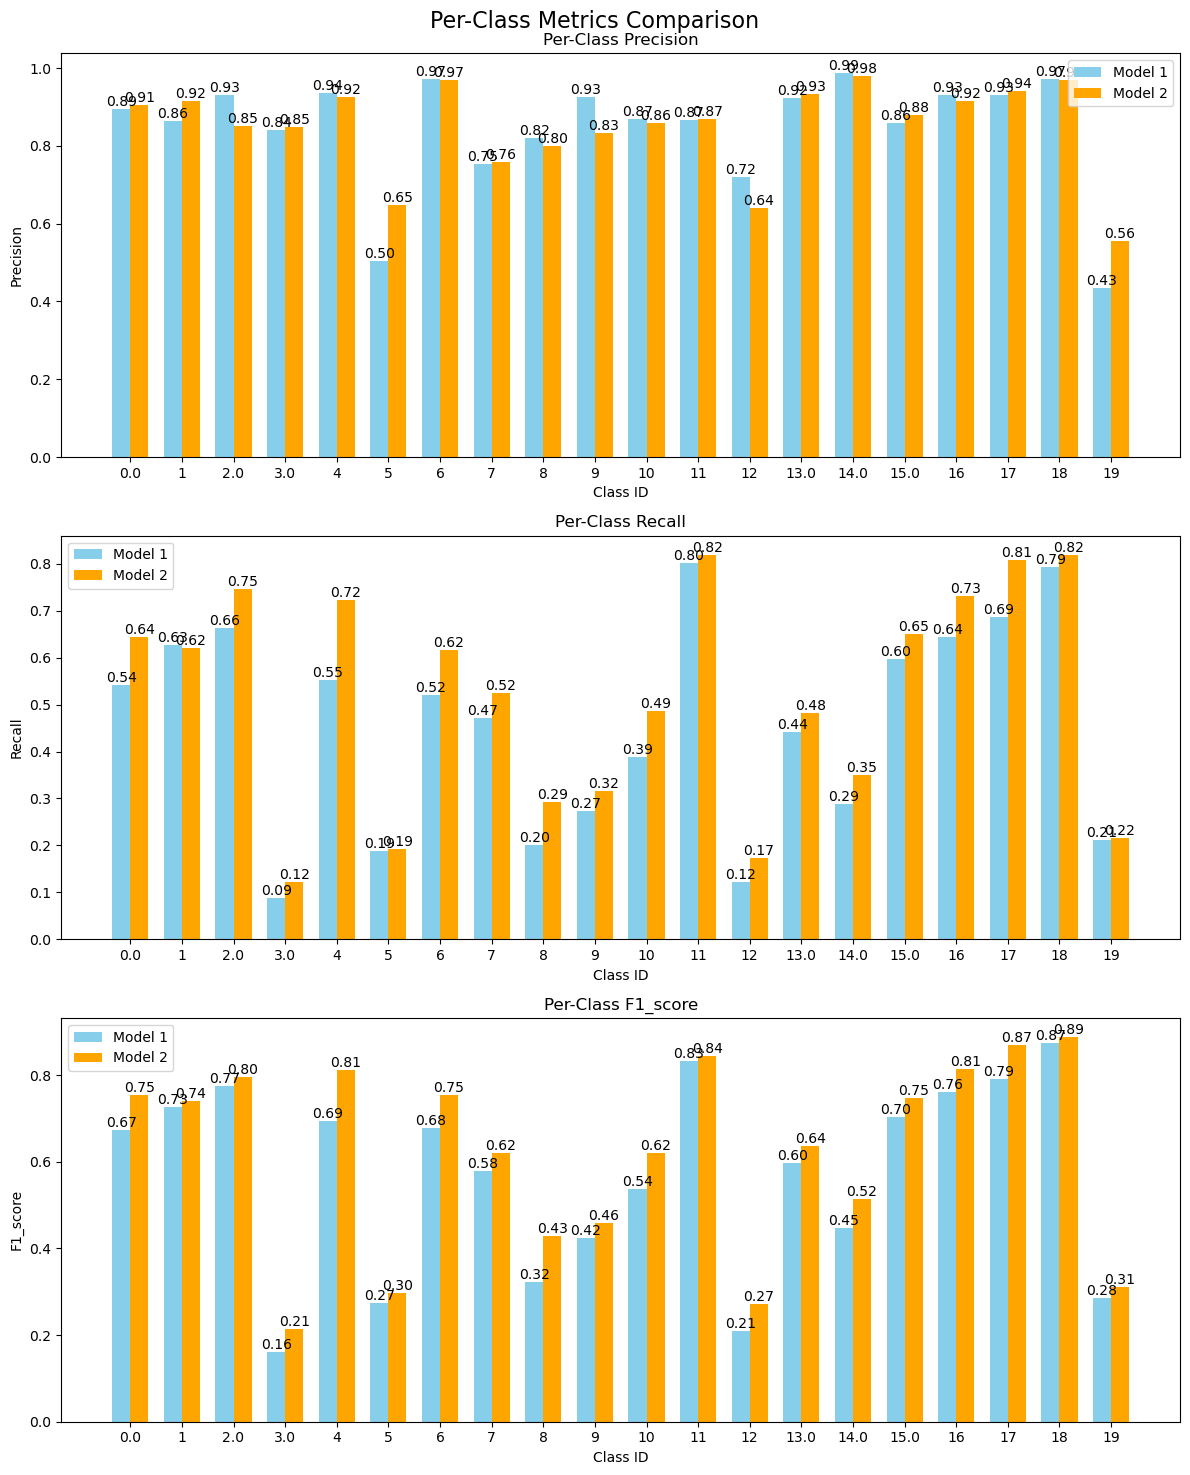

In [ ]:
# Per-class evaluation
class_results1 = evaluate_per_class(model1, dataset_path)
class_results2 = evaluate_per_class(model2, dataset_path)

print("Visualize per-class metrics:")
visualize_per_class_metrics(class_results1, class_results2)

`The bar graphs indicate that Model 2 generally outperforms Model 1 in terms of per-class F1 score and recall. However, when it comes to precision, Model 1 demonstrates comparable, and occasionally slightly better, performance than Model 2. Both models struggle with labels 4 and 19, but Model 2 still shows a noticeable improvement over Model 1 for these specific labels. Overall, Model 2 consistently exhibits superior performance across the majority of per-class metrics.`

Plot Precision-Recall curves:


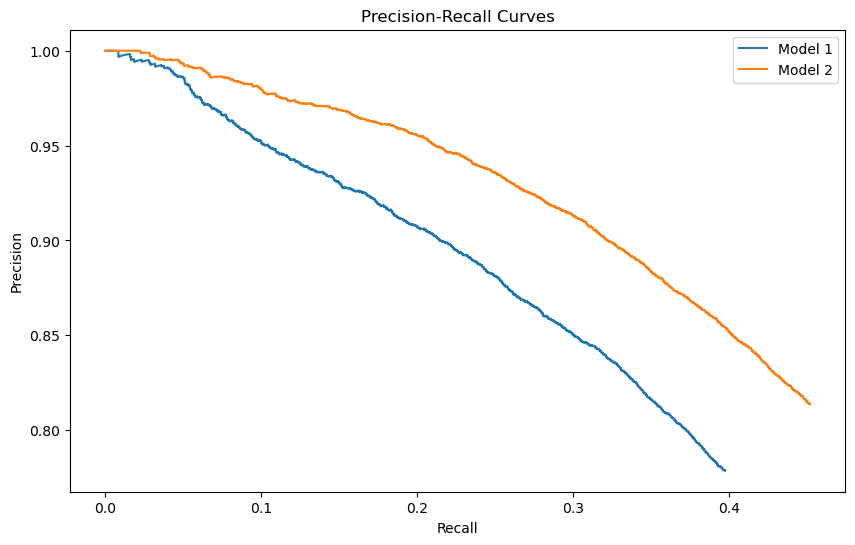

In [ ]:
# Precision-Recall curves
print("Plot Precision-Recall curves:")
precisions1, recalls1, _ = precision_recall_curve(model1, dataset_path)
precisions2, recalls2, _ = precision_recall_curve(model2, dataset_path)
plot_precision_recall_curves(precisions1, recalls1, precisions2, recalls2)

`Based on the graph, Model 2 demonstrates a superior area under the curve (AUC) in the precision-recall plot, signifying a more advantageous balance between precision and recall across different thresholds. This indicates that Model 2 not only achieves higher precision compared to Model 1 but also strikes a more effective trade-off between the two metrics. As a result, Model 2 is likely to deliver more reliable performance in practical scenarios, where the implications of both false negatives and false positives can be substantial.`

Plot error analysis:


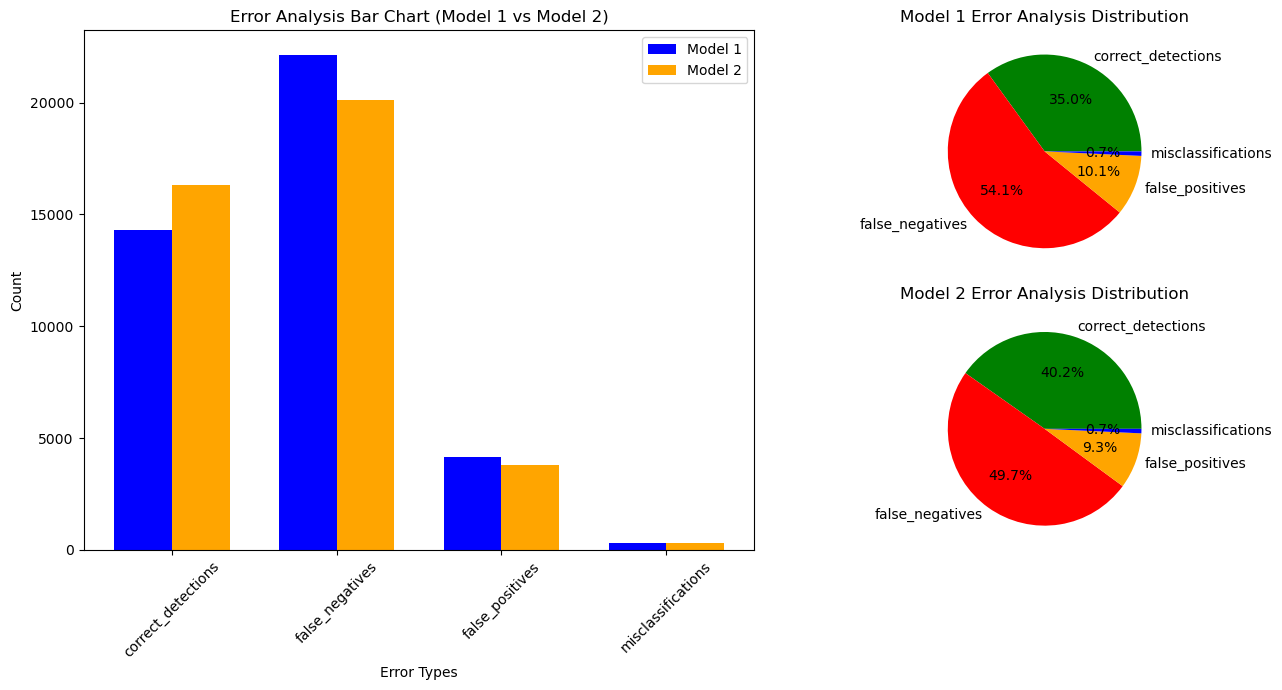

In [ ]:
# Error analysis
print("Plot error analysis:")
error_analysis1 = analyze_errors(model1, dataset_path)
error_analysis2 = analyze_errors(model2, dataset_path)
visualize_error_analysis(error_analysis1, error_analysis2)

`According to the bar graph, both models exhibit a significant number of false negatives, with Model 1 showing comparatively higher levels. Model 2, on the other hand, achieves slightly better correct detections. In terms of false positives and misclassifications, both models are relatively similar. The pie charts further highlight that Model 2 captures a greater proportion of correct detections while sustaining equivalent levels of false positives and misclassifications as Model 1. Also, Model 2 reports a notably lower incidence of false negatives in comparison to Model 1, indicating that it may be the superior model overall.`